# Room segmentation on 3D floor-plan renders

The inputs are **3D isometric renders**, not 2D CAD drawings, so the usual floor-plan
stack (CubiCasa5K, DeepFloorplan and relatives) does not transfer: those expect walls as
thin lines in an orthographic 2D drawing.

What these renders actually look like, measured on the three samples:

- The page background is flat white and separates cleanly by flood fill.
- Walls are extruded, so each wall shows a bright top face plus a shaded vertical face.
  Only the top face is wall-coloured.
- Dominant line directions sit near 0 deg and 90 deg with about 6 deg of spread, so the
  projection is close to orthographic top-down. Rectification is not needed.
- Wall brightness varies between render providers. A global threshold works on two of the
  three samples and fails on the third, whose warm beige floor is nearly as bright as its
  walls. The wall colour is therefore estimated **per image** from a ring just inside the
  plan outline, which is reliably exterior wall.

The pipeline is geometry first, semantics second:

1. `plan_mask` — separate the render from the page, dropping the disclaimer text.
2. `wall_mask` — adaptive wall colour, compact white objects removed, dilated into a barrier.
3. `region_labels` — h-maxima markers plus a distance-transform watershed, then merge
   neighbours whose shared boundary is too wide to be a doorway.
4. `request_labels` / `apply_labels` — a vision-language model names the regions and splits
   open-plan areas, which geometry cannot do by construction.

Steps 1 to 3 need no network and no weights.

In [1]:
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv

from floorplan_seg import (
    PipelineConfig,
    SemanticsConfig,
    SemanticsError,
    overlay_labels,
    segment_floorplan,
)
from floorplan_seg.preprocess import estimate_wall_lab, load_bgr, plan_mask, wall_mask
from floorplan_seg.seeds import region_labels

# Reads OPENAI_API_KEY from .env for the semantic stage; the library itself
# only ever looks at os.environ.
load_dotenv()

PATHS = sorted(Path("data").glob("*.webp"))


def show(images, titles, cols=3, height=5):
    """Display BGR images or masks in a row."""
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * height * 1.3, rows * height))
    for ax, img, title in zip(np.atleast_1d(axes).ravel(), images, titles):
        if img.ndim == 3:
            ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap="gray")
        ax.set_title(title, fontsize=10)
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    fig.tight_layout()


[p.name for p in PATHS]

['heritage towers_a1_1 Bed 1 Bath 593 Sq. Ft..webp',
 'highlandlux-citadel-1 Bed 1 Bath 623 Sq. Ft..webp',
 'limestone ranch_santa fe_625sq.webp']

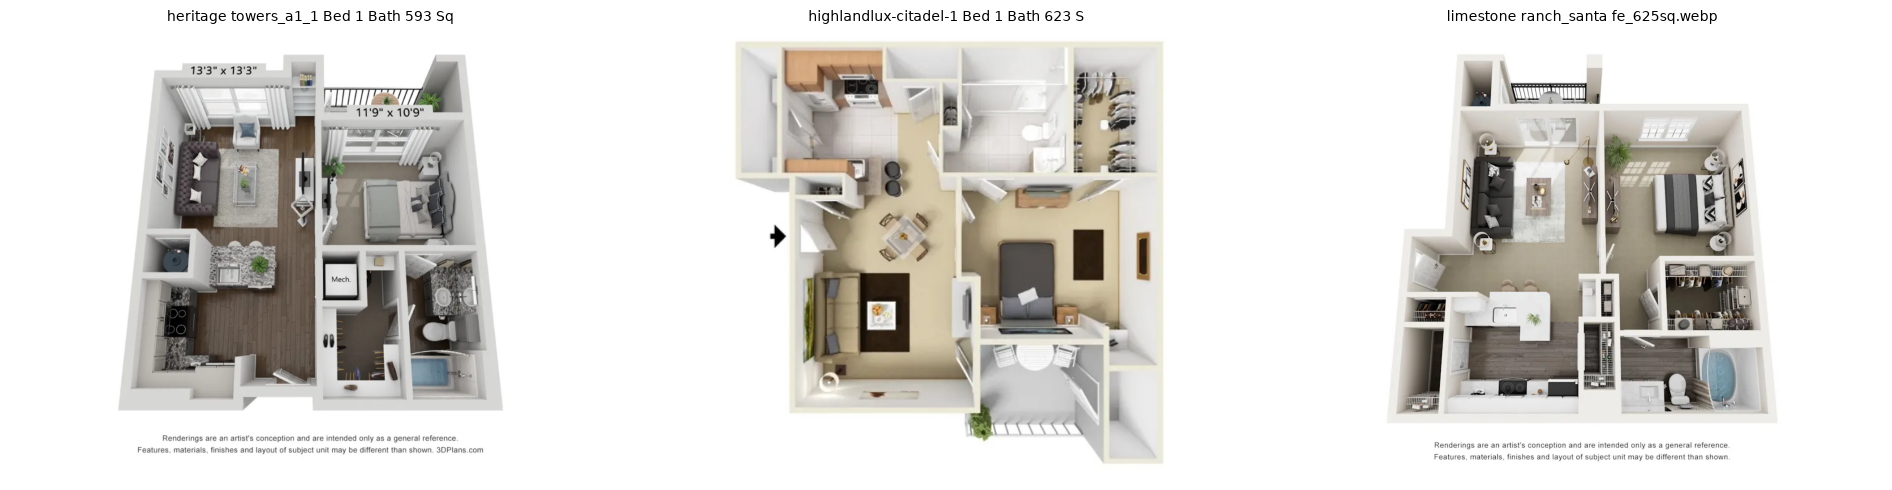

In [2]:
images = [load_bgr(p) for p in PATHS]
show(images, [p.name[:38] for p in PATHS])

## Stage 1-2: plan and walls

The per-image wall colour is the median CIELAB of a ring just inside the plan outline.
Estimating it per image is what keeps the third render from collapsing.

The barrier is the wall mask dilated by a few pixels, which covers the shaded vertical wall
face that is not wall-coloured but still blocks a room.

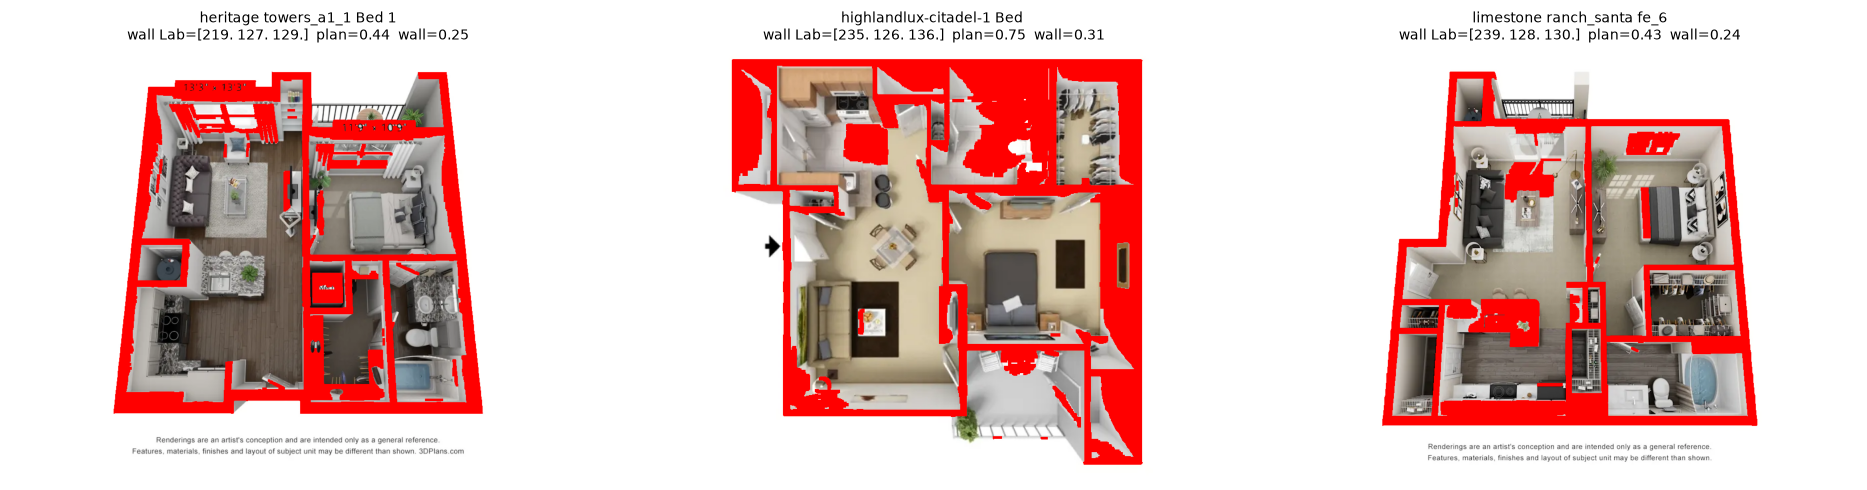

In [3]:
cfg = PipelineConfig()
panels, titles = [], []

for path, bgr in zip(PATHS, images):
    plan = plan_mask(bgr, cfg.preprocess)
    wall, barrier = wall_mask(bgr, plan, cfg.preprocess)
    lab = estimate_wall_lab(bgr, plan, cfg.preprocess)

    tinted = bgr.copy()
    tinted[barrier] = (0, 0, 255)
    panels.append(tinted)
    titles.append(
        f"{path.name[:26]}\nwall Lab={lab.round(0)}  "
        f"plan={plan.mean():.2f}  wall={wall[plan].mean():.2f}"
    )

show(panels, titles)

## Stage 3: geometric regions

Two corrections matter here and both were chosen from measurements on these three images.

Markers come from an **h-maxima** transform rather than local-peak detection: peak detection
fires several times inside one room and produced 30 / 27 / 28 regions, against 12 / 12 / 13
for h-maxima.

Then adjacent regions are merged when the free space along their shared boundary is wider
than a doorway, which brings the counts to roughly the true room counts.

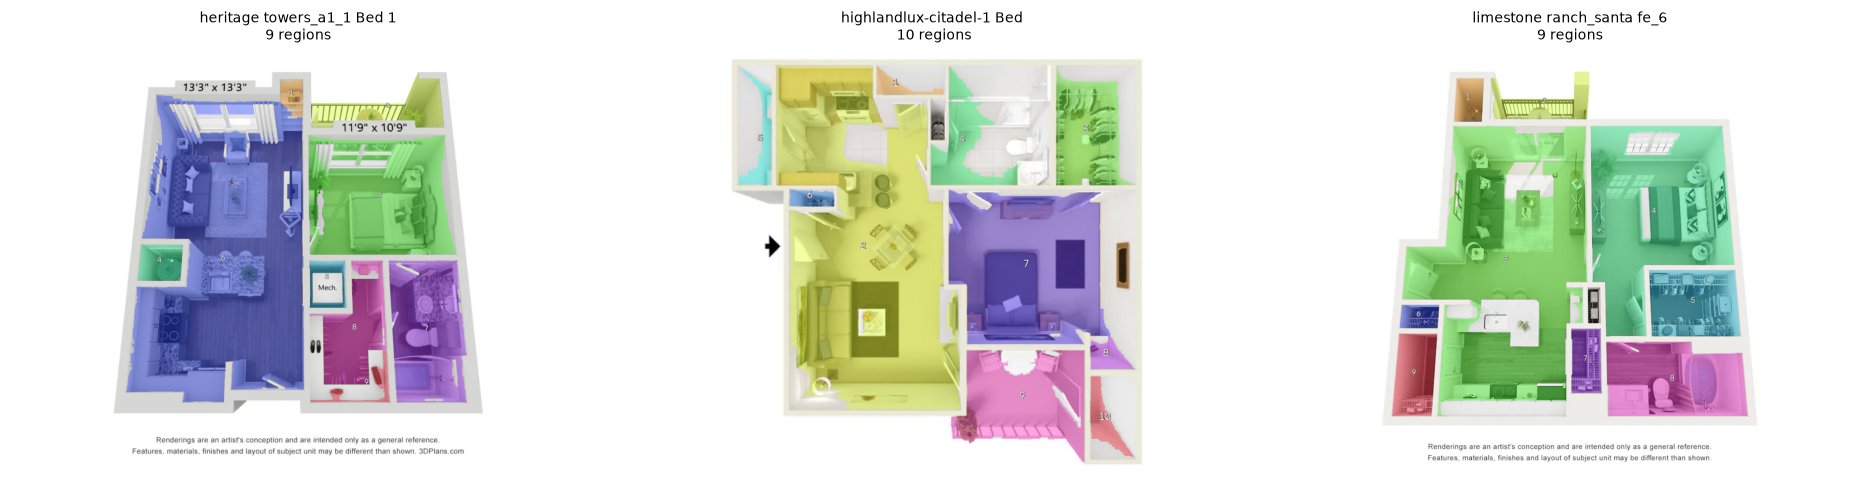

In [4]:
panels, titles = [], []

for path, bgr in zip(PATHS, images):
    plan = plan_mask(bgr, cfg.preprocess)
    _, barrier = wall_mask(bgr, plan, cfg.preprocess)
    labels, _ = region_labels(plan, barrier, cfg.seeds)
    panels.append(overlay_labels(bgr, labels))
    titles.append(f"{path.name[:26]}\n{labels.max()} regions")

show(panels, titles)

## Why SAM 2 is not in the pipeline

The obvious idea is to prompt SAM 2 with one point per region and let it return the room.
That was tried on the first render with `facebook/sam2.1-hiera-large` and 18 point prompts,
keeping all three mask candidates per prompt. None of them behaves like a room:

- the tightest candidate locks onto the object under the point, a rug or a bed, covering
  2 to 8 percent of a region;
- the largest candidate floods through walls, reaching 37 to 63 percent of the whole plan
  with 28 to 48 percent of its own area sitting on top of walls;
- no candidate covered a full room while respecting the walls.

This is expected rather than surprising: SAM is trained on natural images and "a room in an
isometric render" is not an object in that sense. The distance-transform watershed respects
walls by construction and is both cheaper and better here, so SAM 2 was dropped.

## Stage 4: semantics

Geometry cannot split an open-plan kitchen, dining area and living room, because there is no
physical boundary to find. Only furniture says where one ends and the next begins.

The semantic stage sends the clean render plus a numbered overlay to a vision-language model
(set-of-mark prompting), which names each number and returns anchor points for the zones of
any open-plan region. Those zones become geodesic Voronoi cells around the anchors.

Driving that split with the image gradient was the first attempt, hoping the cut would follow
the change in floor finish. It collapses: furniture outlines form closed ridges, one basin
breaks out and floods the region, giving zones of 730 px against 92596 px. The Voronoi split
is blunter but stable.

This needs `OPENAI_API_KEY` in the environment. Without it the cell reports the failure and
the notebook continues with unnamed geometric regions.

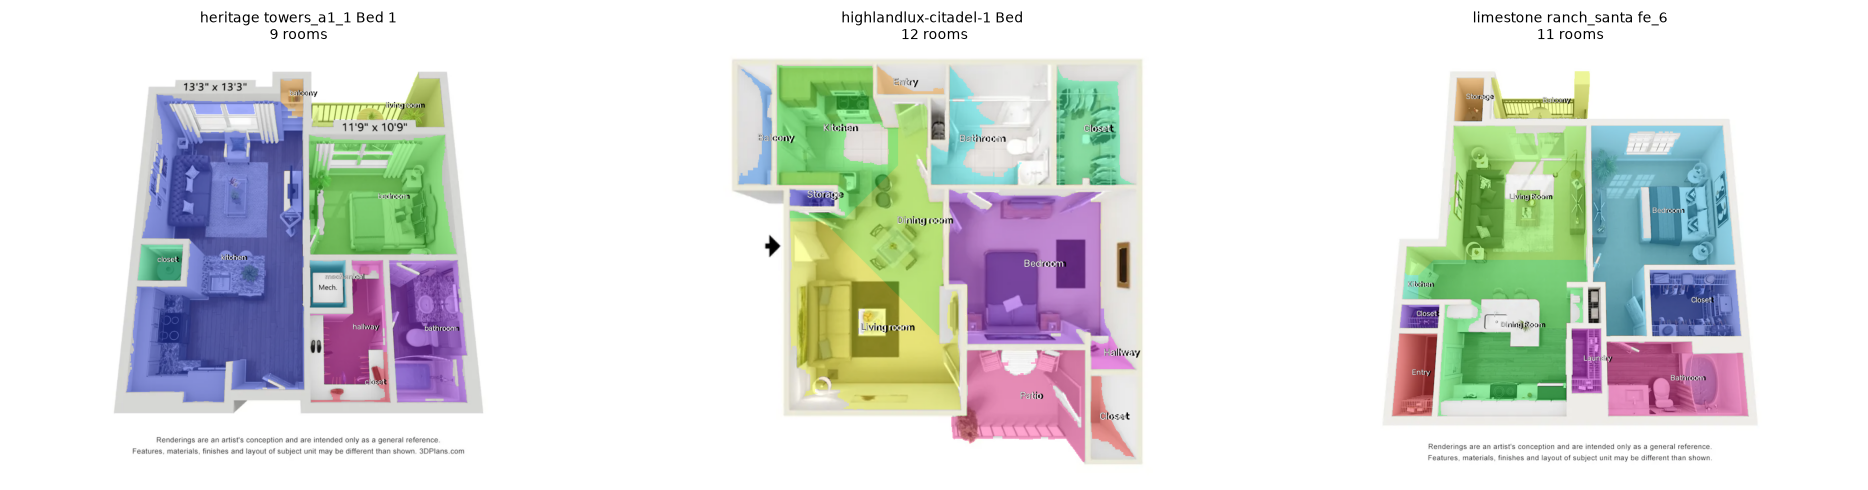

In [5]:
# The semantic stage is off by default; opt in explicitly here.
with_semantics = PipelineConfig(semantics=SemanticsConfig(enabled=True))
try:
    results = [segment_floorplan(p, with_semantics) for p in PATHS]
    labelled = True
except SemanticsError as exc:
    print(f"semantic stage unavailable: {exc}")
    results = [segment_floorplan(p, cfg) for p in PATHS]
    labelled = False

show(
    [overlay_labels(r.image, r.labels, names=r.names or None) for r in results],
    [f"{r.path.name[:26]}\n{len(r.rooms)} rooms" for r in results],
)

### The open-plan split without an API key

To show what the semantic stage produces, the cell below feeds `apply_labels` hand-written
anchors for the first render instead of a model response. This is the part of the stage that
runs locally, so it stays verifiable offline.

In [ ]:
from floorplan_seg.semantics import PlanLabels, RegionLabel, Zone, apply_labels

bgr = images[0]
plan = plan_mask(bgr, cfg.preprocess)
_, barrier = wall_mask(bgr, plan, cfg.preprocess)
geo_labels, _ = region_labels(plan, barrier, cfg.seeds)
open_id = int(np.argmax(np.bincount(geo_labels[geo_labels > 0].ravel())))

stand_in = PlanLabels(
    regions=[
        RegionLabel(
            id=open_id,
            name="open plan",
            zones=[
                Zone(name="living", x=390, y=260),
                Zone(name="kitchen", x=300, y=530),
                Zone(name="dining", x=430, y=430),
                Zone(name="entry", x=480, y=610),
            ],
        ),
        RegionLabel(id=1, name="shelving"),
        RegionLabel(id=2, name="balcony"),
        RegionLabel(id=3, name="bedroom"),
        RegionLabel(id=4, name="closet"),
        RegionLabel(id=5, name="mechanical"),
        RegionLabel(id=7, name="bathroom"),
        RegionLabel(id=8, name="hallway"),
        RegionLabel(id=9, name="tub"),
    ]
)

split_labels, split_names = apply_labels(geo_labels, stand_in, cfg.semantics)
print(f"{geo_labels.max()} geometric regions -> {split_labels.max()} named rooms")

plt.figure(figsize=(11, 8))
plt.imshow(cv.cvtColor(overlay_labels(bgr, split_labels, names=split_names), cv.COLOR_BGR2RGB))
plt.axis("off");

## Validation without ground truth

The file names carry the advertised floor area, so pixel areas convert to square feet. The
total matches by construction, but the per-room figures are a usable sanity check: a bedroom
reported as 4 sq ft means the segmentation broke.

Two of the renders also print room dimensions, which gives an independent check. In the
first plan the bedroom is labelled `11'9" x 10'9"`, that is 126 sq ft, and the pipeline
reports about 112 sq ft. The roughly 11 percent shortfall is expected: extruded walls hide
part of the floor, and the barrier dilation eats a few more pixels.

In [6]:
for r in results:
    print(f"\n{r.path.name}  ({r.total_sqft} sq ft advertised)")
    for room in sorted(r.rooms, key=lambda x: -x.area_px):
        name = room.name or f"region {room.id}"
        print(f"  {name:<22} {room.area_px:>7d} px   {room.area_sqft:>6} sq ft")


heritage towers_a1_1 Bed 1 Bath 593 Sq. Ft..webp  (593.0 sq ft advertised)
  kitchen                 159810 px    315.2 sq ft
  bedroom                  56720 px    111.9 sq ft
  bathroom                 37094 px     73.2 sq ft
  hallway                  20383 px     40.2 sq ft
  living room              12848 px     25.3 sq ft
  closet                    5776 px     11.4 sq ft
  mechanical                2725 px      5.4 sq ft
  balcony                   2697 px      5.3 sq ft
  closet                    2578 px      5.1 sq ft

highlandlux-citadel-1 Bed 1 Bath 623 Sq. Ft..webp  (623.0 sq ft advertised)
  Living room              48275 px    144.7 sq ft
  Bedroom                  47892 px    143.5 sq ft
  Dining room              27649 px     82.9 sq ft
  Kitchen                  27553 px     82.6 sq ft
  Patio                    22391 px     67.1 sq ft
  Closet                   14768 px     44.3 sq ft
  Bathroom                  8552 px     25.6 sq ft
  Balcony                   291

## Limits

Measured on three images, so these are indications rather than statistics.

- Room boundaries land on the visible floor, not on the wall centreline, so areas run low by
  roughly 10 percent. Compensating would need the wall thickness and the extrusion height.
- White sanitary ware and white kitchen cabinets can join the wall network and then survive
  the compactness filter, which eats into bathroom and kitchen regions.
- Balconies, closets and mechanical cupboards are segmented but are only distinguished from
  rooms by the semantic stage.
- Open-plan splitting depends entirely on the vision-language model; with the semantic stage
  off, kitchen, dining and living stay one region.

The natural next step is to run this over a few hundred plans, review the output as
pseudo-labels, and distil it into a single instance-segmentation model, which removes the
API dependency and the per-image latency.